This notebook explores the available data:

1. Download all features for the last year
2. Check correlation 
3. Choose meaningfull features

In [1]:
import yaml
import os
from pathlib import Path

os.chdir(Path.cwd().parent)



In [ ]:
# download data
from src.data.api_requests import fetch_weather_data, fetch_air_quality_data


with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)
    
fetch_weather_data(cfg)
fetch_air_quality_data(cfg)


In [7]:
from src.data.analysis import (assess_missing_data, plot_missing_heatmap,
                               summarize_distributions, plot_histograms,
                               compute_correlation_matrix, plot_correlation_heatmap,
                               correlations_with_target,
                               diurnal_profile, weekly_profile,
                               detect_outliers_zscore, detect_outliers_iqr)
import pandas as pd

# Load joined or per-source data
aq = pd.read_csv("data/raw/air_quality/utrecht_air_quality_2023-01-01_to_2024-01-01.csv", parse_dates=["time"])
wx = pd.read_csv("data/raw/weather/utrecht_weather_2023-01-01_to_2024-01-01.csv", parse_dates=["time"])

# Example: join on time for analysis
df = pd.merge(wx, aq, on=["time", "location"], how="inner")

print(df.columns)


Index(['time', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m',
       'apparent_temperature', 'precipitation', 'rain', 'snowfall',
       'snow_depth', 'weather_code', 'pressure_msl', 'surface_pressure',
       'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
       'et0_fao_evapotranspiration', 'vapour_pressure_deficit',
       'wind_speed_10m', 'wind_speed_100m', 'wind_direction_10m',
       'wind_direction_100m', 'wind_gusts_10m', 'soil_temperature_0_to_7cm',
       'soil_temperature_7_to_28cm', 'soil_temperature_28_to_100cm',
       'soil_temperature_100_to_255cm', 'soil_moisture_0_to_7cm',
       'soil_moisture_7_to_28cm', 'soil_moisture_28_to_100cm',
       'soil_moisture_100_to_255cm', 'location', 'pm10', 'pm2_5',
       'carbon_monoxide', 'carbon_dioxide', 'nitrogen_dioxide',
       'sulphur_dioxide', 'ozone', 'ammonia', 'methane',
       'aerosol_optical_depth', 'uv_index', 'uv_index_clear_sky'],
      dtype='object')


In [ ]:
# 1. Missing data
missing_summary = assess_missing_data(df)
plot_missing_heatmap(df)



=== Distribution summary (numeric columns) ===
                                count         mean        std      min  \
temperature_2m                 8784.0    11.593454   6.490496   -7.400   
relative_humidity_2m           8784.0    80.401867  13.589589   27.000   
dew_point_2m                   8784.0     8.041917   5.456852   -8.300   
apparent_temperature           8784.0     9.046607   7.912404  -12.300   
precipitation                  8784.0     0.142361   0.474014    0.000   
rain                           8784.0     0.138513   0.470116    0.000   
snowfall                       8784.0     0.002694   0.039219    0.000   
snow_depth                     8784.0     0.000775   0.003947    0.000   
weather_code                   8784.0    15.394240  22.829726    0.000   
pressure_msl                   8784.0  1014.004360  11.459908  969.600   
surface_pressure               8784.0  1012.789435  11.443340  968.400   
cloud_cover                    8784.0    69.843124  38.556310    

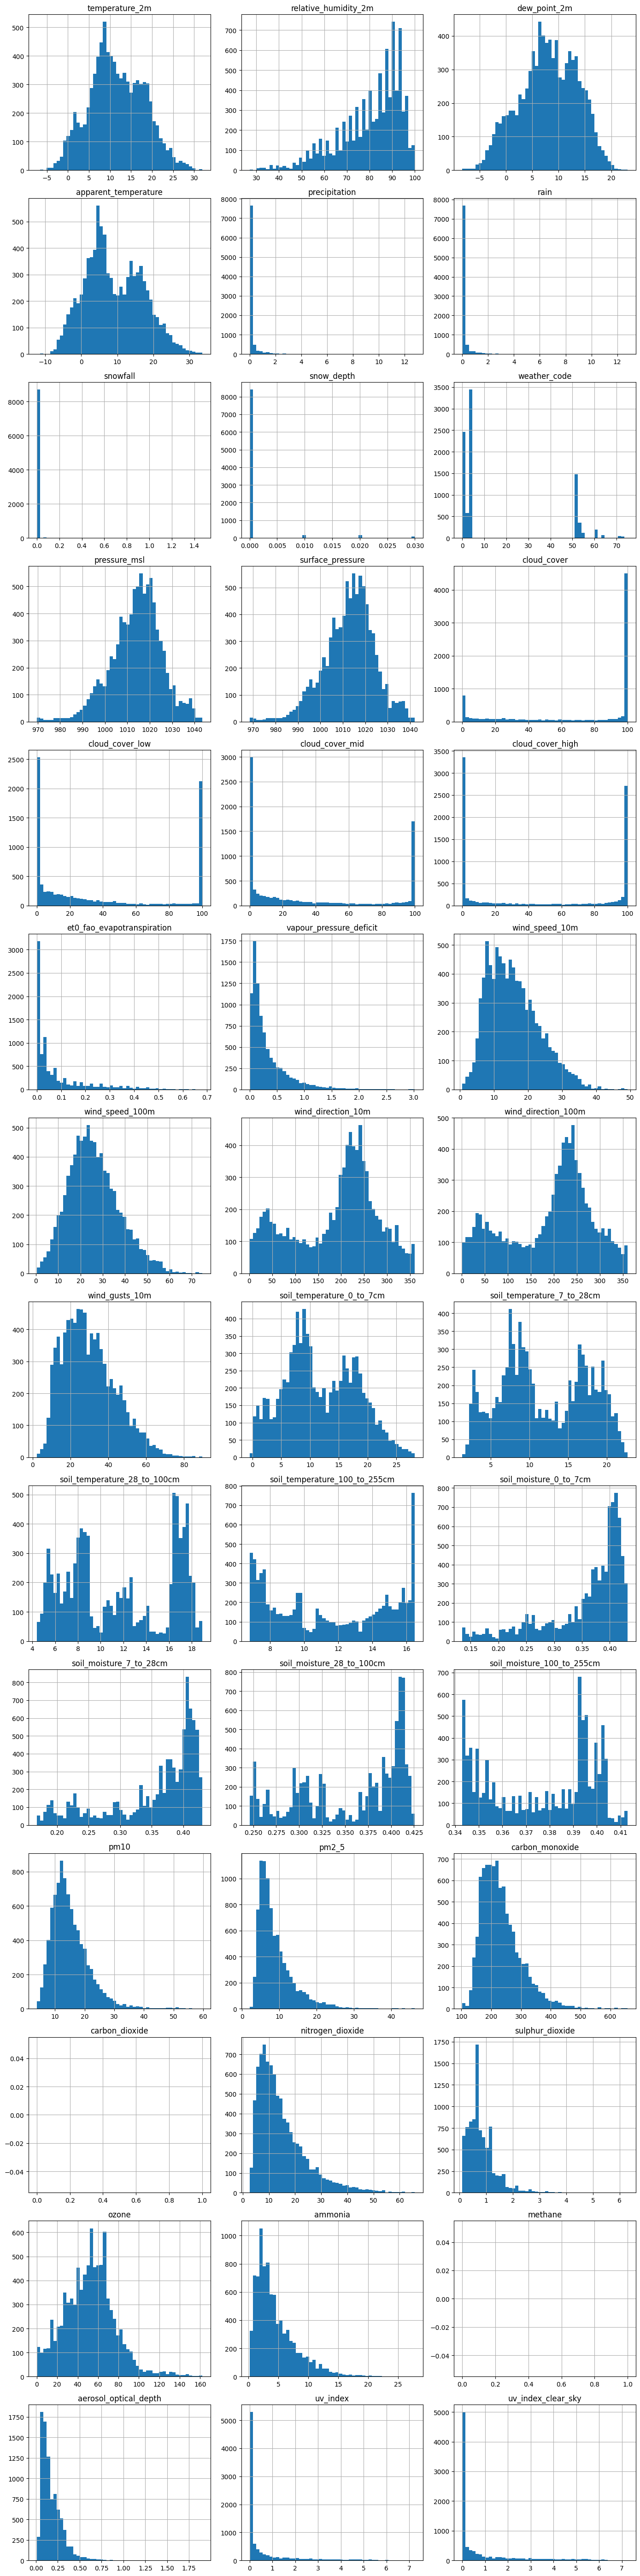

In [3]:
# 2. Distributions
dist_summary = summarize_distributions(df)
plot_histograms(df)



=== Pearson correlation matrix (numeric features) ===
                               temperature_2m  relative_humidity_2m  \
temperature_2m                       1.000000             -0.502493   
relative_humidity_2m                -0.502493              1.000000   
dew_point_2m                         0.887594             -0.055153   
apparent_temperature                 0.984492             -0.419044   
precipitation                        0.015977              0.165128   
rain                                 0.028985              0.160791   
snowfall                            -0.108038              0.047885   
snow_depth                          -0.296021              0.080777   
weather_code                        -0.007376              0.193067   
pressure_msl                        -0.045031             -0.152140   
surface_pressure                    -0.043160             -0.153028   
cloud_cover                         -0.103990              0.258145   
cloud_cover_low        

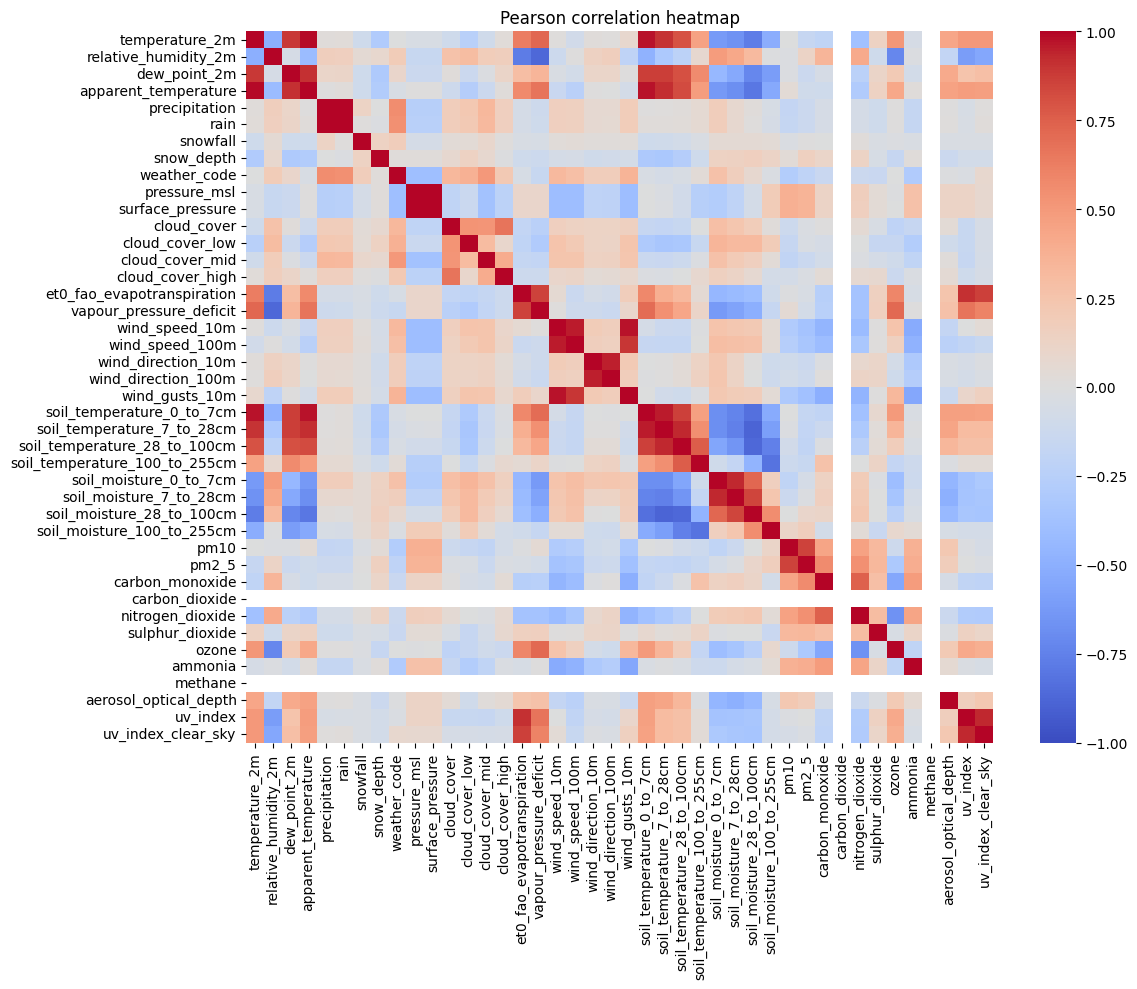

=== Pearson correlations with target 'nitrogen_dioxide' ===
carbon_monoxide                  0.745329
ozone                           -0.664777
pm2_5                            0.541441
wind_gusts_10m                  -0.472912
pm10                             0.453320
ammonia                          0.440863
wind_speed_10m                  -0.417305
relative_humidity_2m             0.413456
temperature_2m                  -0.380458
soil_temperature_0_to_7cm       -0.375424
et0_fao_evapotranspiration      -0.364321
vapour_pressure_deficit         -0.360124
wind_speed_100m                 -0.332841
soil_temperature_7_to_28cm      -0.315026
sulphur_dioxide                  0.298127
uv_index_clear_sky              -0.294199
apparent_temperature            -0.293368
uv_index                        -0.287350
soil_temperature_28_to_100cm    -0.238839
dew_point_2m                    -0.232401
soil_moisture_28_to_100cm        0.228796
soil_moisture_7_to_28cm          0.205900
soil_moisture_0_

In [8]:
# 3. Correlations
corr_matrix = compute_correlation_matrix(df)
plot_correlation_heatmap(df)
corr_with_no2 = correlations_with_target(df, target_col="nitrogen_dioxide")



In [ ]:
# 4. Temporal profiles
columns = [
    'nitrogen_dioxide',
    'pm10', 'pm2_5',
    'carbon_monoxide',
    'ozone',
    'ammonia',
    'temperature_2m',
    'relative_humidity_2m',
    'dew_point_2m',
    'apparent_temperature',
    'cloud_cover',
    'cloud_cover_low',
    'wind_speed_10m',
    'wind_gusts_10m',
    'uv_index',
    'uv_index_clear_sky',
    'vapour_pressure_deficit',
    'et0_fao_evapotranspiration'
]

diurnal = diurnal_profile(df, time_col="time", cols=columns)
weekly = weekly_profile(df, time_col="time", cols=columns)



=== Diurnal profile (mean by hour of day) ===
      nitrogen_dioxide      pm2_5  temperature_2m
hour                                             
0            16.048087   9.045082       10.131694
1            14.341530   9.310929       10.138525
2            13.753279   9.239344        9.875956
3            12.889071   9.099180        9.671038
4            12.611475   9.012568        9.464754
5            13.168306   9.007104        9.275683
6            14.981148   9.311202        9.385792
7            17.425410   9.642350        9.804918
8            18.497541   9.871038       10.439891
9            17.492623  10.003279       11.270765
10           15.553552   9.820765       12.204372
11           13.473497   9.490710       13.075410
12           12.056831   9.169126       13.723770
13           11.318852   8.918306       14.136612
14           11.082240   8.647268       14.372131
15           11.397541   8.330055       14.378962
16           12.639891   8.155191       14.147814
17  

In [ ]:
# 5. Anomalies
z_outliers = detect_outliers_zscore(df, cols=["NO2", "PM10", "temperature_2m"], z_thresh=3.0)
iqr_outliers = detect_outliers_iqr(df, cols=["NO2", "PM10", "temperature_2m"], iqr_multiplier=1.5)